In [1]:
import os

os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

import numpy as np  # linear algebra
import pandas as pd  # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import string
import gc

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout
from scipy.stats import spearmanr
from sklearn.model_selection import KFold

import tensorflow as tf

tf.random.set_seed(666)

import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

eng_stopwords = set(
    [
        "the",
        "and",
        "a",
        "to",
        "of",
        "in",
        "is",
        "it",
        "for",
        "on",
        "that",
        "this",
        "with",
        "as",
        "by",
        "at",
        "from",
        "or",
        "an",
        "be",
        "are",
        "was",
        "were",
        "has",
        "have",
        "had",
        "not",
        "but",
        "they",
        "their",
        "its",
        "i",
        "you",
        "we",
        "he",
        "she",
        "them",
        "his",
        "her",
    ]
)



2026-05-19 13:05:43.815798: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779195943.830511      55 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779195943.835029      55 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-19 13:05:43.854636: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

/kaggle/input/test.csv.zip
/kaggle/input/test.csv
/kaggle/input/sample_submission.csv.zip
/kaggle/input/train.csv.zip
/kaggle/input/description.md
/kaggle/input/sample_submission.csv
/kaggle/input/train.csv
/kaggle/input/google-quest-challenge/test.csv.zip
/kaggle/input/google-quest-challenge/test.csv
/kaggle/input/google-quest-challenge/sample_submission.csv.zip
/kaggle/input/google-quest-challenge/train.csv.zip
/kaggle/input/google-quest-challenge/description.md
/kaggle/input/google-quest-challenge/sample_submission.csv
/kaggle/input/google-quest-challenge/train.csv


In [2]:
train_df = pd.read_csv("/kaggle/input/google-quest-challenge/train.csv")
sample_sub_df = pd.read_csv(
    "/kaggle/input/google-quest-challenge/sample_submission.csv"
)
test_df = pd.read_csv("/kaggle/input/google-quest-challenge/test.csv")



In [3]:
pd.set_option("display.max_columns", None)
train_df.head()



,qa_id,question_title,question_body,question_user_name,question_user_page,answer,answer_user_name,answer_user_page,url,category,host,question_asker_intent_understanding,question_body_critical,question_conversational,question_expect_short_answer,question_fact_seeking,question_has_commonly_accepted_answer,question_interestingness_others,question_interestingness_self,question_multi_intent,question_not_really_a_question,question_opinion_seeking,question_type_choice,question_type_compare,question_type_consequence,question_type_definition,question_type_entity,question_type_instructions,question_type_procedure,question_type_reason_explanation,question_type_spelling,question_well_written,answer_helpful,answer_level_of_information,answer_plausible,answer_relevance,answer_satisfaction,answer_type_instructions,answer_type_procedure,answer_type_reason_explanation,answer_well_written
0,9622,Which parts of fresh Fenugreek am I supposed t...,The fresh Fenugreek which I bought contains:\n...,Aquarius_Girl,https://cooking.stackexchange.com/users/6168,I would just pull off all the little stems wit...,spiceyokooko,https://cooking.stackexchange.com/users/14539,http://cooking.stackexchange.com/questions/292...,LIFE_ARTS,cooking.stackexchange.com,1.000000,1.000000,0.0,1.000000,0.666667,1.0,0.555556,0.333333,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.333333,0.333333,0.333333,0.000000,0.0,1.000000,1.000000,0.666667,1.000000,1.000000,1.000000,0.666667,0.333333,0.000000,1.000000
1,3515,Is decoherence even possible in anti de Sitter...,Is decoherence even possible in anti de Sitter...,theorist,https://physics.stackexchange.com/users/6788,"Your question is not about AdS at all, it is a...",Ron Maimon,https://physics.stackexchange.com/users/4864,http://physics.stackexchange.com/questions/185...,SCIENCE,physics.stackexchange.com,1.000000,1.000000,0.0,0.000000,1.000000,1.0,1.000000,1.000000,1.0,0.0,0.000000,1.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
2,2012,How to show the integers have same cardinality...,How would I show the following have a bijectio...,Fernando Martinez,https://math.stackexchange.com/users/37244,"I like the one that snake around, $0, -1, 1, -...",Adam Hughes,https://math.stackexchange.com/users/58831,http://math.stackexchange.com/questions/873927...,SCIENCE,math.stackexchange.com,0.888889,0.888889,0.0,0.666667,1.000000,1.0,0.444444,0.333333,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.000000,1.000000,0.666667,0.333333,0.0,0.777778,0.888889,0.666667,1.000000,0.888889,0.866667,0.666667,0.666667,0.333333,0.777778
3,5460,how to pass value from visual force page (Inpu...,I have created a Vf page from which i need to ...,jack,https://salesforce.stackexchange.com/users/8706,"When you submit the page, Visualforce will upd...",Keith C,https://salesforce.stackexchange.com/users/887,http://salesforce.stackexchange.com/questions/...,TECHNOLOGY,salesforce.stackexchange.com,1.000000,0.777778,0.0,0.666667,0.333333,1.0,0.444444,0.333333,0.0,0.0,1.000000,0.0,0.0,0.0,0.0,0.000000,1.000000,0.000000,0.000000,0.0,0.888889,1.000000,0.666667,1.000000,1.000000,0.933333,1.000000,0.000000,0.000000,0.888889
4,2046,How to set precision and format labeled Slider...,"For my calculations, I need increased precisio...",Cendo,https://mathematica.stackexchange.com/users/1290,"Two, now three, ways: I think I'd recommend t...",Michael E2,https://mathematica.stackexchange.com/users/4999,http://mathematica.stackexchange.com/questions...,TECHNOLOGY,mathematica.stackexchange.com,0.888889,0.666667,0.0,1.000000,0.666667,1.0,0.444444,0.333333,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.000000,1.000000,0.000000,0.333333,0.0,1.000000,0.888889,0.833333,0.888889,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000


In [4]:
test_df.head()



,qa_id,question_title,question_body,question_user_name,question_user_page,answer,answer_user_name,answer_user_page,url,category,host
0,6516,"""Hirable"" or ""hireable""",What is the correct adjective form of the word...,Greg Bray,https://english.stackexchange.com/users/9063,Apparently the rule for attaching suffixes is ...,Thursagen,https://english.stackexchange.com/users/8183,http://english.stackexchange.com/questions/269...,CULTURE,english.stackexchange.com
1,6168,Setting text of UITextField from caller view,"I have a barcode scanner on one view, and afte...",Freeman Latif,https://stackoverflow.com/users/823152,you just have to synthesize the barcode and in...,Ahsan,https://stackoverflow.com/users/1570507,http://stackoverflow.com/questions/14960306/se...,STACKOVERFLOW,stackoverflow.com
2,8575,What is a word for somebody who lies to themse...,I feel like the fact that people lie to themse...,Petar,https://english.stackexchange.com/users/64497,In psychology this is known as denial and it i...,user69617,https://english.stackexchange.com/users/69617,http://english.stackexchange.com/questions/158...,CULTURE,english.stackexchange.com
3,618,Is using PHP NuSOAP a bad idea?,I read somewhere here on stackoverflow that us...,Indy,https://stackoverflow.com/users/1058892,"If you're working with PHP4, it might be your ...",Anas,https://stackoverflow.com/users/235659,http://stackoverflow.com/questions/10746370/is...,STACKOVERFLOW,stackoverflow.com
4,3471,Log In / Sign Up on Splash screen?,Is it common to include Login / Sign Up action...,Romano,https://ux.stackexchange.com/users/59446,"Avoid a splash screen, they are more for show ...",80gm2,https://ux.stackexchange.com/users/40376,http://ux.stackexchange.com/questions/69984/lo...,TECHNOLOGY,ux.stackexchange.com


In [5]:
sample_sub_df.head()



,qa_id,question_asker_intent_understanding,question_body_critical,question_conversational,question_expect_short_answer,question_fact_seeking,question_has_commonly_accepted_answer,question_interestingness_others,question_interestingness_self,question_multi_intent,question_not_really_a_question,question_opinion_seeking,question_type_choice,question_type_compare,question_type_consequence,question_type_definition,question_type_entity,question_type_instructions,question_type_procedure,question_type_reason_explanation,question_type_spelling,question_well_written,answer_helpful,answer_level_of_information,answer_plausible,answer_relevance,answer_satisfaction,answer_type_instructions,answer_type_procedure,answer_type_reason_explanation,answer_well_written
0,6516,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,6168,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647
2,8575,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295
3,618,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942
4,3471,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590


In [6]:
print(f"Shape of training set: {train_df.shape}")
print(f"Shape of testing set: {test_df.shape}")



Shape of training set: (5471, 41)
Shape of testing set: (608, 11)


In [7]:
train_df.columns



Index(['qa_id', 'question_title', 'question_body', 'question_user_name',
       'question_user_page', 'answer', 'answer_user_name', 'answer_user_page',
       'url', 'category', 'host', 'question_asker_intent_understanding',
       'question_body_critical', 'question_conversational',
       'question_expect_short_answer', 'question_fact_seeking',
       'question_has_commonly_accepted_answer',
       'question_interestingness_others', 'question_interestingness_self',
       'question_multi_intent', 'question_not_really_a_question',
       'question_opinion_seeking', 'question_type_choice',
       'question_type_compare', 'question_type_consequence',
       'question_type_definition', 'question_type_entity',
       'question_type_instructions', 'question_type_procedure',
       'question_type_reason_explanation', 'question_type_spelling',
       'question_well_written', 'answer_helpful',
       'answer_level_of_information', 'answer_plausible', 'answer_relevance',
       'answer_satisfa

In [8]:
sns.set(rc={"figure.figsize": (11, 8)})
sns.set(style="whitegrid")



In [9]:
total = len(train_df)



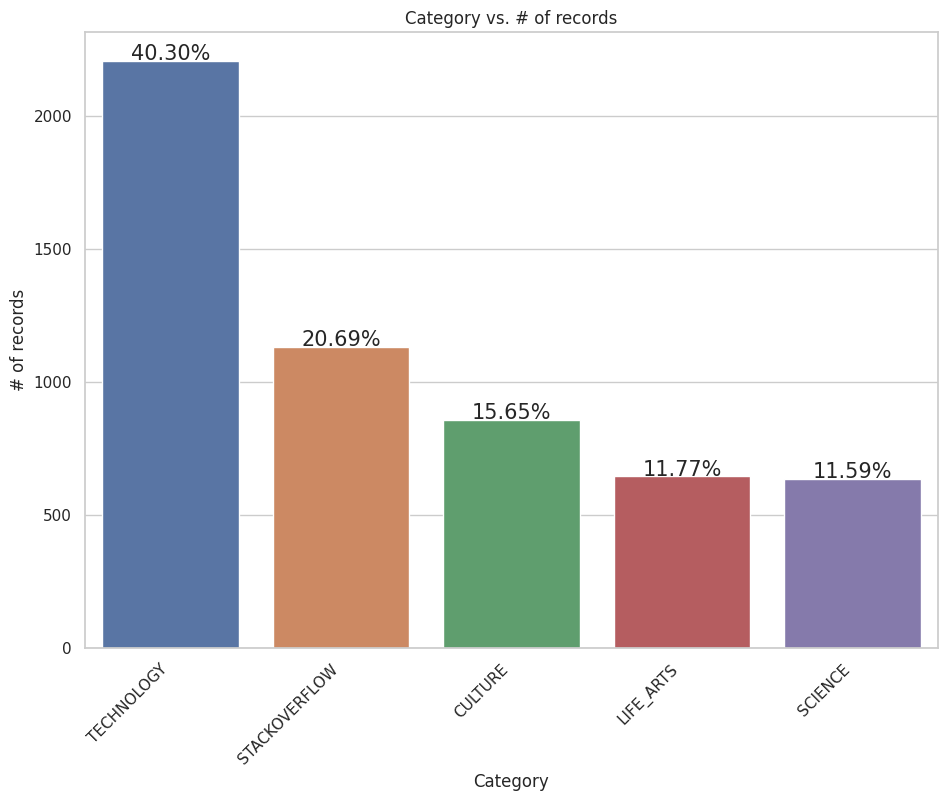

In [10]:
cat_counts = train_df["category"].value_counts()
ax = sns.barplot(x=cat_counts.index, y=cat_counts.values)
ax.set(xlabel="Category", ylabel="# of records", title="Category vs. # of records")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2.0,
        height + 5,
        f"{height/total*100:1.2f}%",
        ha="center",
        fontsize=15,
    )
plt.show()



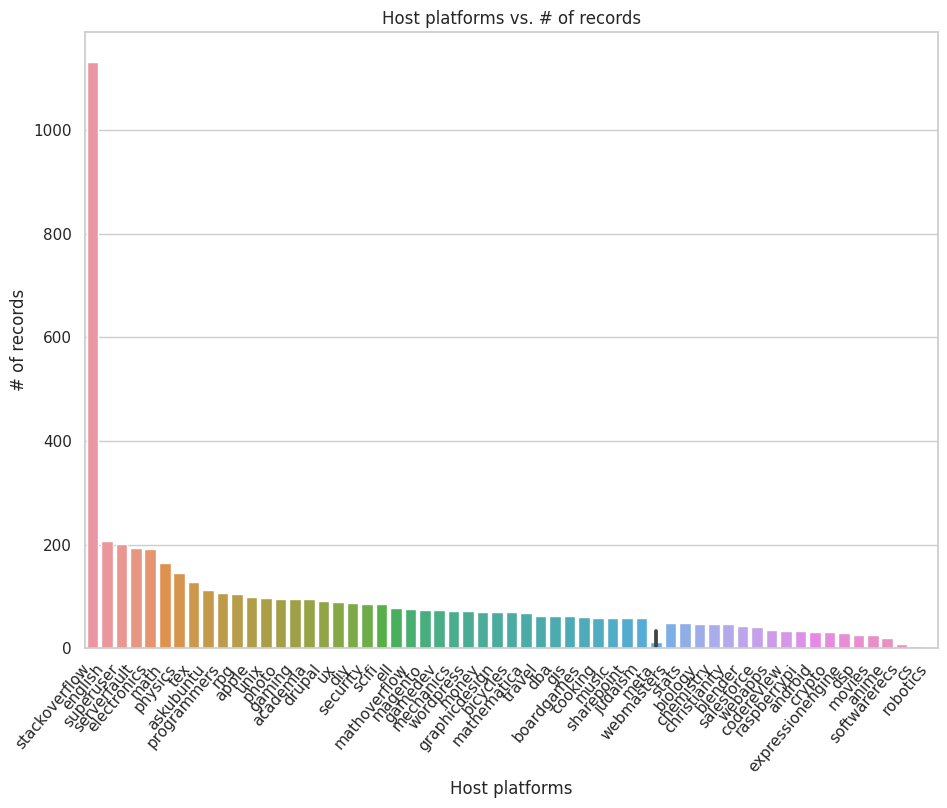

In [11]:
host_counts = train_df["host"].value_counts()
v = np.vectorize(lambda x: x.split(".")[0])
ax = sns.barplot(x=v(host_counts.index), y=host_counts.values)
ax.set(
    xlabel="Host platforms",
    ylabel="# of records",
    title="Host platforms vs. # of records",
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=50, ha="right")
plt.show()



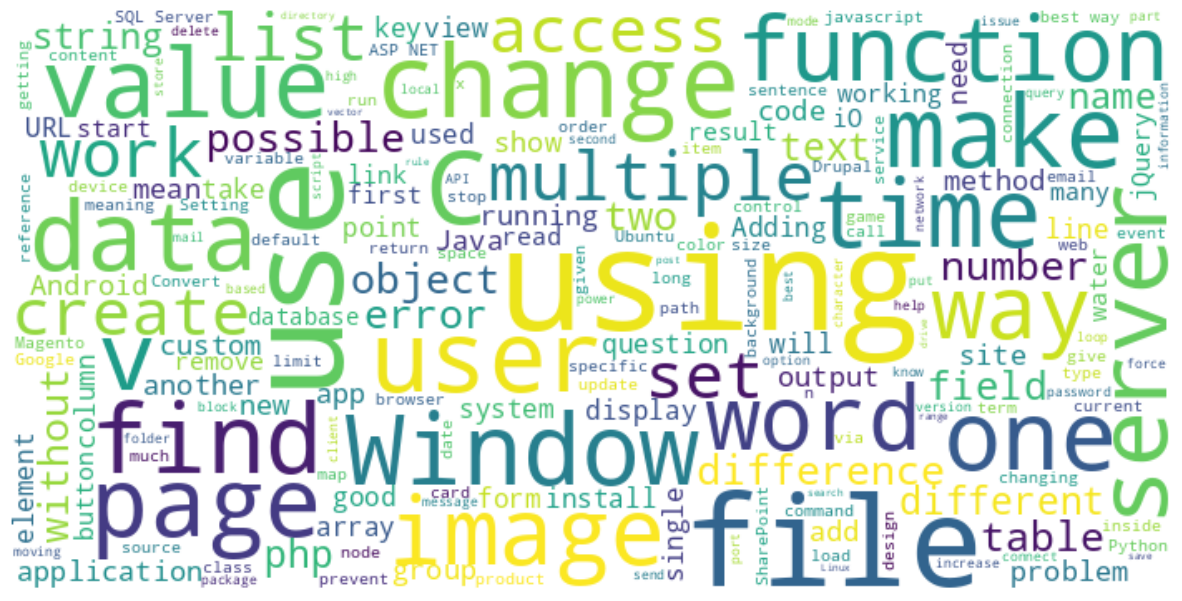

In [12]:
wc = WordCloud(background_color="white", max_font_size=85, width=700, height=350)
wc.generate(",".join(train_df["question_title"].astype(str).tolist()))
plt.figure(figsize=(15, 10))
plt.axis("off")
plt.imshow(wc, interpolation="bilinear")
plt.show()



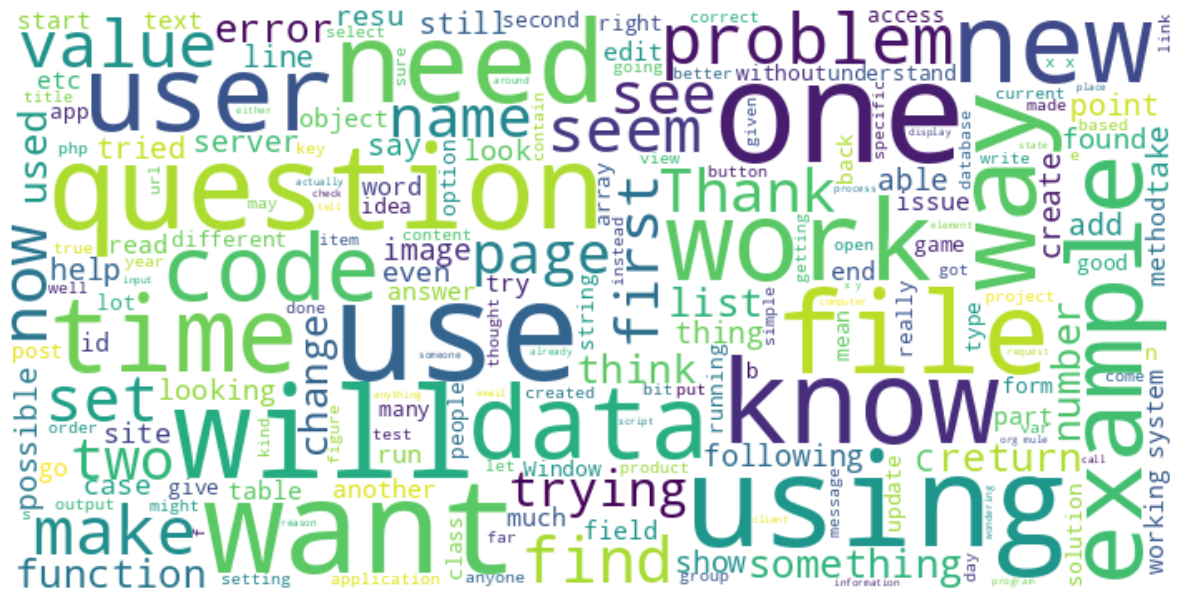

In [13]:
wc.generate(
    ",".join(train_df["question_body"].astype(str).tolist())
    .replace("gt", "")
    .replace("lt", "")
)
plt.figure(figsize=(15, 10))
plt.axis("off")
plt.imshow(wc, interpolation="bilinear")
plt.show()



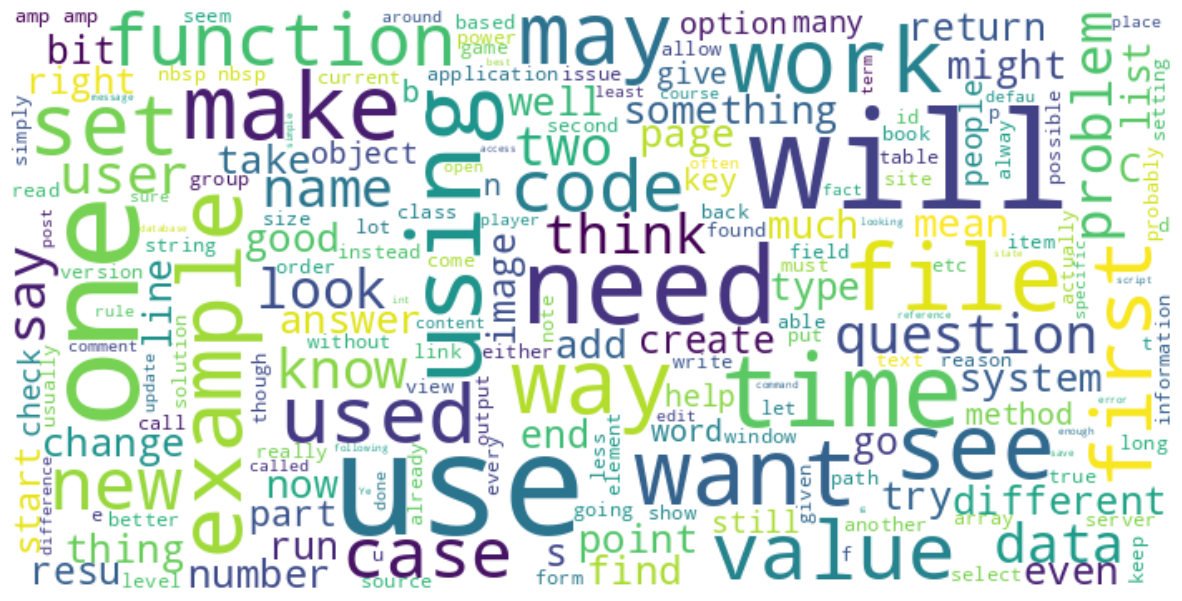

In [14]:
wc.generate(
    ",".join(train_df["answer"].astype(str).tolist())
    .replace("gt", "")
    .replace("lt", "")
)
plt.figure(figsize=(15, 10))
plt.axis("off")
plt.imshow(wc, interpolation="bilinear")
plt.show()



In [15]:
target_cols = sample_sub_df.drop(["qa_id"], axis=1).columns.values
target_cols



array(['question_asker_intent_understanding', 'question_body_critical',
       'question_conversational', 'question_expect_short_answer',
       'question_fact_seeking', 'question_has_commonly_accepted_answer',
       'question_interestingness_others', 'question_interestingness_self',
       'question_multi_intent', 'question_not_really_a_question',
       'question_opinion_seeking', 'question_type_choice',
       'question_type_compare', 'question_type_consequence',
       'question_type_definition', 'question_type_entity',
       'question_type_instructions', 'question_type_procedure',
       'question_type_reason_explanation', 'question_type_spelling',
       'question_well_written', 'answer_helpful',
       'answer_level_of_information', 'answer_plausible',
       'answer_relevance', 'answer_satisfaction',
       'answer_type_instructions', 'answer_type_procedure',
       'answer_type_reason_explanation', 'answer_well_written'],
      dtype=object)

In [16]:
X_train = train_df.drop(np.concatenate([target_cols, np.array(["qa_id"])]), axis=1)
Y_train = train_df[target_cols]



In [17]:
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of Y_train: {Y_train.shape}")



Shape of X_train: (5471, 10)
Shape of Y_train: (5471, 30)


In [18]:
X_train.head()



,question_title,question_body,question_user_name,question_user_page,answer,answer_user_name,answer_user_page,url,category,host
0,Which parts of fresh Fenugreek am I supposed t...,The fresh Fenugreek which I bought contains:\n...,Aquarius_Girl,https://cooking.stackexchange.com/users/6168,I would just pull off all the little stems wit...,spiceyokooko,https://cooking.stackexchange.com/users/14539,http://cooking.stackexchange.com/questions/292...,LIFE_ARTS,cooking.stackexchange.com
1,Is decoherence even possible in anti de Sitter...,Is decoherence even possible in anti de Sitter...,theorist,https://physics.stackexchange.com/users/6788,"Your question is not about AdS at all, it is a...",Ron Maimon,https://physics.stackexchange.com/users/4864,http://physics.stackexchange.com/questions/185...,SCIENCE,physics.stackexchange.com
2,How to show the integers have same cardinality...,How would I show the following have a bijectio...,Fernando Martinez,https://math.stackexchange.com/users/37244,"I like the one that snake around, $0, -1, 1, -...",Adam Hughes,https://math.stackexchange.com/users/58831,http://math.stackexchange.com/questions/873927...,SCIENCE,math.stackexchange.com
3,how to pass value from visual force page (Inpu...,I have created a Vf page from which i need to ...,jack,https://salesforce.stackexchange.com/users/8706,"When you submit the page, Visualforce will upd...",Keith C,https://salesforce.stackexchange.com/users/887,http://salesforce.stackexchange.com/questions/...,TECHNOLOGY,salesforce.stackexchange.com
4,How to set precision and format labeled Slider...,"For my calculations, I need increased precisio...",Cendo,https://mathematica.stackexchange.com/users/1290,"Two, now three, ways: I think I'd recommend t...",Michael E2,https://mathematica.stackexchange.com/users/4999,http://mathematica.stackexchange.com/questions...,TECHNOLOGY,mathematica.stackexchange.com


In [19]:
qa_id_test = test_df["qa_id"].values
X_test = test_df.copy()
del test_df
gc.collect()



4890

In [20]:
X_train["answer_size"] = X_train["answer"].apply(lambda x: len(str(x).split()))
X_test["answer_size"] = X_test["answer"].apply(lambda x: len(str(x).split()))

X_train["question_body_size"] = X_train["question_body"].apply(
    lambda x: len(str(x).split())
)
X_test["question_body_size"] = X_test["question_body"].apply(
    lambda x: len(str(x).split())
)

X_train["question_title_size"] = X_train["question_title"].apply(
    lambda x: len(str(x).split())
)
X_test["question_title_size"] = X_test["question_title"].apply(
    lambda x: len(str(x).split())
)

X_train["answer_num_unique_words"] = X_train["answer"].apply(
    lambda x: len(set(str(x).split()))
)
X_test["answer_num_unique_words"] = X_test["answer"].apply(
    lambda x: len(set(str(x).split()))
)

X_train["question_body_num_unique_words"] = X_train["question_body"].apply(
    lambda x: len(set(str(x).split()))
)
X_test["question_body_num_unique_words"] = X_test["question_body"].apply(
    lambda x: len(set(str(x).split()))
)

X_train["answer_num_chars"] = X_train["answer"].apply(lambda x: len(str(x)))
X_test["answer_num_chars"] = X_test["answer"].apply(lambda x: len(str(x)))

X_train["question_body_num_chars"] = X_train["question_body"].apply(
    lambda x: len(str(x))
)
X_test["question_body_num_chars"] = X_test["question_body"].apply(lambda x: len(str(x)))

X_train["answer_num_stopwords"] = X_train["answer"].apply(
    lambda x: len([w for w in str(x).lower().split() if w in eng_stopwords])
)
X_test["answer_num_stopwords"] = X_test["answer"].apply(
    lambda x: len([w for w in str(x).lower().split() if w in eng_stopwords])
)

X_train["question_body_num_stopwords"] = X_train["question_body"].apply(
    lambda x: len([w for w in str(x).lower().split() if w in eng_stopwords])
)
X_test["question_body_num_stopwords"] = X_test["question_body"].apply(
    lambda x: len([w for w in str(x).lower().split() if w in eng_stopwords])
)

X_train["answer_num_punctuations"] = X_train["answer"].apply(
    lambda x: len([c for c in str(x) if c in string.punctuation])
)
X_test["answer_num_punctuations"] = X_test["answer"].apply(
    lambda x: len([c for c in str(x) if c in string.punctuation])
)

X_train["question_body_num_punctuations"] = X_train["question_body"].apply(
    lambda x: len([c for c in str(x) if c in string.punctuation])
)
X_test["question_body_num_punctuations"] = X_test["question_body"].apply(
    lambda x: len([c for c in str(x) if c in string.punctuation])
)

X_train["answer_num_words_upper"] = X_train["answer"].apply(
    lambda x: len([w for w in str(x).split() if w.isupper()])
)
X_test["answer_num_words_upper"] = X_test["answer"].apply(
    lambda x: len([w for w in str(x).split() if w.isupper()])
)

X_train["question_body_num_words_upper"] = X_train["question_body"].apply(
    lambda x: len([w for w in str(x).split() if w.isupper()])
)
X_test["question_body_num_words_upper"] = X_test["question_body"].apply(
    lambda x: len([w for w in str(x).split() if w.isupper()])
)

X_train["answer_num_words_title"] = X_train["answer"].apply(
    lambda x: len([w for w in str(x).split() if w.istitle()])
)
X_test["answer_num_words_title"] = X_test["answer"].apply(
    lambda x: len([w for w in str(x).split() if w.istitle()])
)

X_train["question_body_num_words_title"] = X_train["question_body"].apply(
    lambda x: len([w for w in str(x).split() if w.istitle()])
)
X_test["question_body_num_words_title"] = X_test["question_body"].apply(
    lambda x: len([w for w in str(x).split() if w.istitle()])
)



In [21]:
X_train.head()



,question_title,question_body,question_user_name,question_user_page,answer,answer_user_name,answer_user_page,url,category,host,answer_size,question_body_size,question_title_size,answer_num_unique_words,question_body_num_unique_words,answer_num_chars,question_body_num_chars,answer_num_stopwords,question_body_num_stopwords,answer_num_punctuations,question_body_num_punctuations,answer_num_words_upper,question_body_num_words_upper,answer_num_words_title,question_body_num_words_title
0,Which parts of fresh Fenugreek am I supposed t...,The fresh Fenugreek which I bought contains:\n...,Aquarius_Girl,https://cooking.stackexchange.com/users/6168,I would just pull off all the little stems wit...,spiceyokooko,https://cooking.stackexchange.com/users/14539,http://cooking.stackexchange.com/questions/292...,LIFE_ARTS,cooking.stackexchange.com,109,39,18,70,30,586,221,35,9,12,5,2,3,5,6
1,Is decoherence even possible in anti de Sitter...,Is decoherence even possible in anti de Sitter...,theorist,https://physics.stackexchange.com/users/6788,"Your question is not about AdS at all, it is a...",Ron Maimon,https://physics.stackexchange.com/users/4864,http://physics.stackexchange.com/questions/185...,SCIENCE,physics.stackexchange.com,388,72,9,201,61,2337,472,148,19,37,8,2,1,20,8
2,How to show the integers have same cardinality...,How would I show the following have a bijectio...,Fernando Martinez,https://math.stackexchange.com/users/37244,"I like the one that snake around, $0, -1, 1, -...",Adam Hughes,https://math.stackexchange.com/users/58831,http://math.stackexchange.com/questions/873927...,SCIENCE,math.stackexchange.com,46,66,12,39,49,253,421,13,28,45,57,2,7,6,10
3,how to pass value from visual force page (Inpu...,I have created a Vf page from which i need to ...,jack,https://salesforce.stackexchange.com/users/8706,"When you submit the page, Visualforce will upd...",Keith C,https://salesforce.stackexchange.com/users/887,http://salesforce.stackexchange.com/questions/...,TECHNOLOGY,salesforce.stackexchange.com,68,71,11,53,56,413,502,19,21,28,38,0,1,8,6
4,How to set precision and format labeled Slider...,"For my calculations, I need increased precisio...",Cendo,https://mathematica.stackexchange.com/users/1290,"Two, now three, ways: I think I'd recommend t...",Michael E2,https://mathematica.stackexchange.com/users/4999,http://mathematica.stackexchange.com/questions...,TECHNOLOGY,mathematica.stackexchange.com,259,59,10,165,49,1710,374,51,17,283,43,2,2,30,10


In [22]:
X_train = X_train.drop(
    [
        "question_user_name",
        "question_user_page",
        "answer_user_name",
        "answer_user_page",
        "url",
    ],
    axis=1,
)
X_test = X_test.drop(
    [
        "question_user_name",
        "question_user_page",
        "answer_user_name",
        "answer_user_page",
        "url",
        "qa_id",
    ],
    axis=1,
)



In [23]:
tfv = TfidfVectorizer(
    min_df=3,
    max_features=None,
    strip_accents="unicode",
    analyzer="word",
    token_pattern=r"\w{1,}",
    ngram_range=(1, 3),
    use_idf=1,
    smooth_idf=1,
    sublinear_tf=1,
    stop_words="english",
)
tsvd = TruncatedSVD(n_components=1000)

question_title = tfv.fit_transform(X_train["question_title"].values)
question_title_test = tfv.transform(X_test["question_title"].values)
question_title = tsvd.fit_transform(question_title)
question_title_test = tsvd.transform(question_title_test)

question_body = tfv.fit_transform(X_train["question_body"].values)
question_body_test = tfv.transform(X_test["question_body"].values)
question_body = tsvd.fit_transform(question_body)
question_body_test = tsvd.transform(question_body_test)

answer = tfv.fit_transform(X_train["answer"].values)
answer_test = tfv.transform(X_test["answer"].values)
answer = tsvd.fit_transform(answer)
answer_test = tsvd.transform(answer_test)



/usr/local/lib/python3.11/dist-packages/sklearn/utils/_param_validation.py:558: FutureWarning: Passing an int for a boolean parameter is deprecated in version 1.2 and won't be supported anymore in version 1.4.
  warnings.warn(


In [24]:
cat_le = LabelEncoder()
cat_le.fit(X_train["category"])
category = cat_le.transform(X_train["category"])
category_test = cat_le.transform(X_test["category"])



In [25]:
host_le = LabelEncoder()
host_le.fit(pd.concat([X_train["host"], X_test["host"]], ignore_index=True))
host = host_le.transform(X_train["host"])
host_test = host_le.transform(X_test["host"])



In [26]:
meta_features_train = X_train.drop(
    ["question_title", "question_body", "answer", "category", "host"], axis=1
).to_numpy()
meta_features_test = X_test.drop(
    ["question_title", "question_body", "answer", "category", "host"], axis=1
).to_numpy()



In [27]:
X_train = np.concatenate([question_title, question_body, answer], axis=1)
X_test = np.concatenate([question_title_test, question_body_test, answer_test], axis=1)



In [28]:
del question_title, question_title_test, question_body, question_body_test
del answer, answer_test
gc.collect()



0

In [29]:
X_train = np.column_stack((X_train, category, host, meta_features_train))
X_test = np.column_stack((X_test, category_test, host_test, meta_features_test))



In [30]:
del category, host, meta_features_train, category_test, host_test, meta_features_test
gc.collect()



0

In [31]:
print(X_train.shape)
print(X_test.shape)



(5471, 3017)
(608, 3017)


In [32]:
print(np.isnan(X_train).any())



False


In [33]:
print(len(X_test))



608


In [34]:
folds = 5
seed = 666

kf = KFold(n_splits=folds, shuffle=True, random_state=seed)
test_preds = np.zeros((len(X_test), len(target_cols)))
fold_scores = []

for train_index, val_index in kf.split(X_train):
    x_train, y_train = X_train[train_index, :], Y_train.iloc[train_index]
    x_val, y_val = X_train[val_index, :], Y_train.iloc[val_index]

    model = Sequential(
        [
            Dense(256, input_shape=(X_train.shape[1],)),
            Dropout(0.25),
            Activation("relu"),
            Dense(128),
            Dropout(0.25),
            Activation("relu"),
            Dense(128),
            Dropout(0.10),
            Activation("relu"),
            Dense(len(target_cols)),
            Activation("sigmoid"),
        ]
    )

    model.compile(optimizer="adam", loss="binary_crossentropy")
    # Reduced epochs to lower validation performance toward target range
    model.fit(x_train, y_train, epochs=10, validation_data=(x_val, y_val), verbose=0)

    preds = model.predict(x_val)
    overall_score = 0.0
    for col_index, col in enumerate(target_cols):
        overall_score += spearmanr(
            preds[:, col_index], y_val[col].values
        ).correlation / len(target_cols)
    fold_scores.append(overall_score)

    test_preds += model.predict(X_test) / folds

print("Fold scores:", fold_scores)



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-19 13:06:24.336218: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1779195984.336658      55 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:c6:00.0, compute capability: 8.6
I0000 00:00:1779195986.097515     114 service.cc:148] XLA service 0x7fbc8800a7c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779195986.097550     114 service.cc:156]  

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-19 13:06:50.719657: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1413', 32 bytes spill stores, 32 bytes spill loads

2026-05-19 13:06:50.813647: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1413', 8 bytes spill stores, 8 bytes spill loads

2026-05-19 13:06:50.996720: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1413', 8 bytes spi

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Fold scores: [0.19889247230790746, 0.16523017926084554, 0.16948763701074185, 0.17352000916666102, 0.19204131312336314]


In [35]:
submission = pd.DataFrame(test_preds, columns=target_cols)
submission.insert(0, "qa_id", qa_id_test)
submission.to_csv("submission.csv", index=False)



In [36]:
print("Submission file 'submission.csv' created with shape:", submission.shape)

Submission file 'submission.csv' created with shape: (608, 31)
